# This notebook is the implementation of:
- OpenAI's GPT-4o
- Meta's Llama 3.3 70B
- Anthropic's Claude 3.5 Haiku
- Mistral Large
- BERT w chunking
- Longformer

# This portion covers training and evaluation of BERT model:

In [1]:
import os
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel, AdamW, get_linear_schedule_with_warmup
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cpu


In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

class DataPreparator:
    def __init__(self, model_name: str, max_length: int = 256):
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.max_length = max_length

    def split_data(self, data, label_col='label', text_col='text', test_size=0.2, random_state=42):
        """
        Splits data into train and validation sets. Avoids stratification if class counts are too low.
        """
        df = pd.DataFrame(data)
        stratify_col = None

        # Check if stratification is possible
        if df[label_col].value_counts().min() > 1:
            stratify_col = df[label_col]

        train_df, val_df = train_test_split(
            df, 
            test_size=test_size, 
            random_state=random_state, 
            stratify=stratify_col
        )
        return train_df, val_df
    def tokenize(self, texts):
        """
        Applies the BERT tokenizer to a list of texts.
        Returns a dictionary with 'input_ids' and 'attention_mask'.
        """
        return self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

In [3]:
class BertClassifier(nn.Module):
    """
    A simple classification model on top of a BERT base.
    """
    def __init__(self, model_name: str, num_labels: int):
        """
        :param model_name: The name of the pretrained model (FinBERT, LegalBERT, etc.).
        :param num_labels: The number of possible labels/classes.
        """
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        """
        Forward pass of the model.
        """
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output  # shape: (batch_size, hidden_size)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        output_dict = {"logits": logits}

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
            output_dict["loss"] = loss

        return output_dict

In [5]:
class DocumentDataset(Dataset):
    """
    PyTorch Dataset for our documents.
    Expects 'input_ids', 'attention_mask', and integer 'labels'.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def train_model(model, train_dataset, val_dataset, epochs=2, batch_size=4, lr=1e-5):
    """
    Custom training loop for the classification model.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, 
                                                num_warmup_steps=0,
                                                num_training_steps=total_steps)

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, labels=labels)
            loss = outputs["loss"]
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}, Training loss: {avg_train_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask, labels=labels)
                val_loss += outputs["loss"].item()

                logits = outputs["logits"]
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / total
        print(f"Validation loss: {avg_val_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

    return model, val_loader

In [8]:
import pandas as pd
import os
import random
from transformers import BertTokenizer
from torch.utils.data import DataLoader
import torch

# Load the file-topic mapping used in the GPT-4o and Llama evaluation
file_topic_mapping = pd.read_csv("final_file_topic_mapping.csv")  # Ensure this is the same mapping used in evaluate_files()

# Randomly select 100 files for evaluation
random.seed(42)  # Ensure consistency
eval_files = file_topic_mapping.sample(n=100, random_state=42)

# Get the remaining files for training
train_files = file_topic_mapping[~file_topic_mapping["file_name"].isin(eval_files["file_name"])]

# Print some stats
print(f"Training files: {len(train_files)}, Evaluation files: {len(eval_files)}")

Training files: 259, Evaluation files: 100


In [10]:
# Function to search for the correct file path recursively
def find_file_recursive(base_folder, file_name):
    """
    Recursively searches for the given file inside the base folder.
    Returns the correct file path if found, otherwise returns None.
    """
    for root, _, files in os.walk(base_folder):
        if file_name in files:
            return os.path.join(root, file_name)
    return None  # Return None if file not found

# Read and load text data using recursive search
def load_data(files_df, base_folder):
    data_entries = []
    for _, row in files_df.iterrows():
        file_name = row["file_name"]
        file_path = find_file_recursive(base_folder, file_name)

        if not file_path:
            print(f"Skipping missing file: {file_name}")
            continue

        with open(file_path, "r", encoding="utf-8") as f:
            text_content = f.read()

        data_entries.append({"text": text_content, "label": row["folder_name"].strip()})

    return data_entries

base_folder = "Cleaned_Data_v2"

train_data_entries = load_data(train_files, base_folder)
eval_data_entries = load_data(eval_files, base_folder)

# Prepare label mappings
unique_labels = sorted(file_topic_mapping["folder_name"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

print("Unique labels found:", unique_labels)

# Initialize DataPreparator
model_name = "ProsusAI/finbert"
prep = DataPreparator(model_name=model_name, max_length=128)

# Tokenize training & evaluation sets
train_df, val_df = prep.split_data(train_data_entries, label_col="label")
train_encodings = prep.tokenize(train_df["text"].tolist())
val_encodings = prep.tokenize(val_df["text"].tolist())

train_labels = train_df["label"].map(label2id).tolist()
val_labels = val_df["label"].map(label2id).tolist()

train_dataset = DocumentDataset(train_encodings, train_labels)
val_dataset = DocumentDataset(val_encodings, val_labels)

# Train Model
num_labels = len(unique_labels)
model = BertClassifier(model_name, num_labels=num_labels)

trained_model, _ = train_model(model, train_dataset, val_dataset, epochs=2, batch_size=2, lr=2e-5)

# **Inference on the same 100 evaluation files**
eval_encodings = prep.tokenize([entry["text"] for entry in eval_data_entries])
eval_labels = [label2id[entry["label"]] for entry in eval_data_entries]
eval_dataset = DocumentDataset(eval_encodings, eval_labels)

eval_loader = DataLoader(eval_dataset, batch_size=4)

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in eval_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask, labels=labels)
        preds = torch.argmax(outputs["logits"], axis=1)

        predictions.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

# Convert predictions to label names
predicted_labels = [id2label[p] for p in predictions]
true_labels = [id2label[t] for t in true_labels]

# Save results for direct comparison
results_df = pd.DataFrame({"file_name": eval_files["file_name"], "expected_topic": true_labels, "predicted_topic": predicted_labels})
results_df.to_csv("bert_topic_evaluation_results.csv", index=False)
print("BERT evaluation results saved to bert_topic_evaluation_results.csv")

Unique labels found: ['Administrative', 'Annual Reports', 'Anti Money Laundering', 'Audit Reports', 'Client Agreements', 'Consumer Finance', 'Derivatives', 'Employment', 'Financial Regulations', 'Financial Statements', 'Investment and Market Research', 'Loans', 'Marketing and Public Communication', 'Mergers and Acquisitions', 'Non-Disclosure Agreements (NDA)', 'Operational', 'Partnerships', 'Regulatory and Compliance', 'Risk Management', 'Strategic', 'Taxation', 'Technology']


/Users/jaron/miniconda3/lib/python3.11/site-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/2:   0%|                                    | 0/104 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Epoch 1/2: 100%|██████████████████████████| 104/104 [00:56<00:00,  1.83it/s]


Epoch 1, Training loss: 2.7387
Validation loss: 2.3192, Validation Accuracy: 0.4615


Epoch 2/2: 100%|██████████████████████████| 104/104 [00:55<00:00,  1.87it/s]


Epoch 2, Training loss: 2.1976
Validation loss: 2.1286, Validation Accuracy: 0.4423
BERT evaluation results saved to bert_topic_evaluation_results.csv


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

results_df = pd.read_csv("bert_topic_evaluation_results.csv")

# Model names for evaluation
model_columns = ["predicted_topic"]
model_names = ["BERT"]

metrics_data = []

for model_name, model_column in zip(model_names, model_columns):
    report = classification_report(
        results_df["expected_topic"], 
        results_df[model_column], 
        output_dict=True, 
        zero_division=0
    )
    
    metrics_data.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"]
    })

metrics_df = pd.DataFrame(metrics_data)

# Print numerical evaluation results
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))

Evaluation Metrics:
Model  Accuracy  Precision   Recall  F1-Score
 BERT      0.45   0.081268 0.110717  0.085507


# This portion covers training and evaluation of Longformer:

In [14]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd

class LongformerClassifier(nn.Module):
    """
    A simple classification model on top of a Longformer base.
    """
    def __init__(self, model_name: str, num_labels: int):
        """
        :param model_name: The name of the pretrained model.
        :param num_labels: Number of classification labels.
        """
        super().__init__()
        self.longformer = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.longformer.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        """
        Forward pass of the model.
        """
        outputs = self.longformer(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token representation
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        output_dict = {"logits": logits}

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
            output_dict["loss"] = loss

        return output_dict

class DataPreparator:
    def __init__(self, model_name: str, max_length: int = 512):
        """
        Handles data preparation, including tokenization and splitting.
        """
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.max_length = max_length

    def split_data(self, data, label_col='label', text_col='text', test_size=0.2, random_state=42):
        """
        Splits data into training and validation sets.
        """
        df = pd.DataFrame(data)
        stratify_col = df[label_col] if df[label_col].nunique() > 1 else None
        train_df, val_df = train_test_split(
            df, test_size=test_size, random_state=random_state, stratify=stratify_col
        )
        return train_df, val_df

    def tokenize(self, texts):
        """
        Tokenizes input texts using Longformer's tokenizer.
        """
        return self.tokenizer(
            texts, padding=True, truncation=True, max_length=self.max_length, return_tensors='pt'
        )

class DocumentDataset(Dataset):
    """
    PyTorch Dataset for documents.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [15]:
import os
import torch

# Load file-topic mapping
file_topic_mapping = pd.read_csv("final_file_topic_mapping.csv")

# Select 100 evaluation files (same as GPT-4o, Llama, and BERT)
eval_files = file_topic_mapping.sample(n=100, random_state=42)

# Use remaining files for training
train_files = file_topic_mapping[~file_topic_mapping["file_name"].isin(eval_files["file_name"])]

# Function to find file paths recursively
def find_file_recursive(base_folder, file_name):
    for root, _, files in os.walk(base_folder):
        if file_name in files:
            return os.path.join(root, file_name)
    return None

# Load text data
def load_data(files_df, base_folder):
    data_entries = []
    for _, row in files_df.iterrows():
        file_path = find_file_recursive(base_folder, row["file_name"])
        if not file_path:
            print(f"Skipping missing file: {row['file_name']}")
            continue

        with open(file_path, "r", encoding="utf-8") as f:
            text_content = f.read()

        data_entries.append({"text": text_content, "label": row["folder_name"].strip()})

    return data_entries

base_folder = "Cleaned_Data_v2"
train_data_entries = load_data(train_files, base_folder)
eval_data_entries = load_data(eval_files, base_folder)

# Prepare label mappings
unique_labels = sorted(file_topic_mapping["folder_name"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

# Initialize DataPreparator
model_name = "allenai/longformer-base-4096"
prep = DataPreparator(model_name=model_name, max_length=512)

# Tokenize training & evaluation sets
train_df, val_df = prep.split_data(train_data_entries, label_col="label")
train_encodings = prep.tokenize(train_df["text"].tolist())
val_encodings = prep.tokenize(val_df["text"].tolist())

train_labels = train_df["label"].map(label2id).tolist()
val_labels = val_df["label"].map(label2id).tolist()

train_dataset = DocumentDataset(train_encodings, train_labels)
val_dataset = DocumentDataset(val_encodings, val_labels)

In [16]:
from transformers import AdamW, get_scheduler
from tqdm import tqdm

def train_model(model, train_dataset, val_dataset, epochs=2, batch_size=2, lr=2e-5):
    """
    Trains the Longformer model.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=lr)
    scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=len(train_loader) * epochs)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, labels=labels)
            loss = outputs["loss"]
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}, Training loss: {avg_train_loss:.4f}")

    return model

num_labels = len(unique_labels)
longformer_model = LongformerClassifier(model_name, num_labels=num_labels)
trained_model = train_model(longformer_model, train_dataset, val_dataset, epochs=2, batch_size=2, lr=2e-5)

/Users/jaron/miniconda3/lib/python3.11/site-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/2: 100%|██████████████████████████| 104/104 [07:11<00:00,  4.15s/it]


Epoch 1, Training loss: 2.6716


Epoch 2/2: 100%|██████████████████████████| 104/104 [07:47<00:00,  4.49s/it]

Epoch 2, Training loss: 2.1123


In [21]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Ensure model is in evaluation mode
trained_model.eval()

# Tokenize evaluation data
eval_encodings = prep.tokenize([entry["text"] for entry in eval_data_entries])
eval_labels = [label2id[entry["label"]] for entry in eval_data_entries]
eval_dataset = DocumentDataset(eval_encodings, eval_labels)

# Create DataLoader for batch processing
eval_loader = DataLoader(eval_dataset, batch_size=4)

# Store predictions and ground truth labels
predictions = []
true_labels = []

with torch.no_grad():
    for batch in eval_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Perform inference
        outputs = trained_model(input_ids, attention_mask)
        preds = torch.argmax(outputs["logits"], axis=1)

        predictions.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

# Convert predictions to label names
predicted_labels = [id2label[p] for p in predictions]
true_labels = [id2label[t] for t in true_labels]

# Save results for direct comparison
results_df = pd.DataFrame({"file_name": eval_files["file_name"], "expected_topic": true_labels, "predicted_topic": predicted_labels})
results_df.to_csv("longformer_topic_evaluation_results.csv", index=False)
print("Longformer evaluation results saved to longformer_topic_evaluation_results.csv")

# Model names for evaluation
model_columns = ["predicted_topic"]
model_names = ["Longformer"]

metrics_data = []

for model_name, model_column in zip(model_names, model_columns):
    report = classification_report(
        results_df["expected_topic"], 
        results_df[model_column], 
        output_dict=True, 
        zero_division=0
    )
    
    metrics_data.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"]
    })

metrics_df = pd.DataFrame(metrics_data)

# Print numerical evaluation results
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))

Longformer evaluation results saved to longformer_topic_evaluation_results.csv
Evaluation Metrics:
     Model  Accuracy  Precision  Recall  F1-Score
Longformer      0.45   0.061111 0.11275  0.074159


# This portion covers the evaluation of the larger LLMs:

In [26]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import os
import pandas as pd
import json
from dotenv import load_dotenv
import boto3
from botocore.config import Config
from botocore.exceptions import ClientError
from openai import OpenAI
import random

load_dotenv("codes.env")

# AWS credentials
aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

# OpenAI credentials
openai_client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY")
)

# AWS Bedrock model configurations
MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"
MODEL_ID_CLAUDE = "us.anthropic.claude-3-5-haiku-20241022-v1:0"
# arn:aws:bedrock:us-west-2:874280117166:inference-profile/us.anthropic.claude-3-5-haiku-20241022-v1:0
MODEL_ID_TITAN = "amazon.titan-text-lite-v1"

# Prevent Bedrock timeout
config = Config(read_timeout=1000)

client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

# Load file-topic mapping
mapping_file_path = 'final_file_topic_mapping.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)

# Read a .txt file's content
def read_txt_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

# Map outputs to categories
def map_to_category(predicted_output):
    predicted_output = predicted_output.lower().strip()
    for topic in unique_topics:
        if topic.lower() in predicted_output:
            return topic
    return "unknown"

# Function to search for the correct file path recursively
def find_file_recursive(base_folder, expected_topic, file_name):
    """
    Recursively searches for the given file inside the base folder.
    Returns the correct file path if found, otherwise returns None.
    """
    for root, _, files in os.walk(base_folder):
        if file_name in files:
            return os.path.join(root, file_name)
    return None  # Return None if file not found

In [30]:
## BASE

# Define max token limit per request
MAX_TOKENS = 45000  # Adjust as needed

# Function to truncate text to prevent exceeding token limits
def truncate_text(text, max_tokens=MAX_TOKENS):
    words = text.split()
    if len(words) > max_tokens:
        print(f"Warning: Truncating input text to {max_tokens} tokens.")
        return " ".join(words[:max_tokens])
    return text

# OpenAI's GPT-4o
def evaluate_topic_with_gpt4o(file_content):
    try:
        response = openai_client.chat.completions.create(
            messages=[
                {"role": "system", "content": "You are an expert document classifier."},
                {"role": "user", "content": f"Classify the following text into only one of these topics: {unique_topics_str}. \n{file_content}"}, 
                # test trying to give description of each topic 
                # generate explanation to labels 
            ],
            model="gpt-4o",
            temperature=0,
            top_p=1,
        )
        predicted_topic = response.choices[0].message.content
        return map_to_category(predicted_topic)
    except Exception as e:
        print(f"Error calling OpenAI API: {e}")
        return "unknown"

# AWS Bedrock (Meta's Llama 3.3)
def evaluate_topic_with_llama(file_content):
    try:
        file_content = truncate_text(file_content)
        prompt = f"Classify the following text into only one of these topics: {unique_topics_str}. \n{file_content}"
        formatted_prompt = f"""
            <|begin_of_text|>
            <|start_header_id|>user<|end_header_id|>
            {prompt}
            <|eot_id|>
            <|start_header_id|>assistant<|end_header_id|>
            """
        response = client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
                "top_p": 1,
            }),
            contentType="application/json"
        )
        response_body = json.loads(response['body'].read())
        predicted_topic = response_body.get("generation", "").strip()
        if not predicted_topic:
            print("Empty response from AWS Bedrock Llama, defaulting to unknown.")
        return map_to_category(predicted_topic)
    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "unknown"

# validate and trim input text since both Titan and Claude models have length limits on AWS Bedrock
def validate_and_trim_text(input_text, max_length):
    if len(input_text) > max_length:
        # print(f"Input text length of {len(input_text)} exceeds max length {max_length} of model. Trimming it.")
        return input_text[:max_length]
    return input_text

# AWS Bedrock (Amazon's Titan Text G1 Premier)
def evaluate_topic_with_titan(file_content):
    try:
        # Titan API's maximum input length
        MAX_LENGTH_TITAN = 3000
        validated_text = truncate_text(file_content, MAX_LENGTH_TITAN)
        
        # prompt for the model
        prompt = (
            f"Classify the following text into only one of these topics: {unique_topics_str}. \n"
            f"{validated_text}"
        )

        conversation = [
            {
                "role": "user",
                "content": [{"text": prompt}],
            }
        ]

        response = client.converse(
            modelId=MODEL_ID_TITAN,
            messages=conversation,
            inferenceConfig={
                "maxTokens": 512,
                "temperature": 0,
                "topP": 1,
            },
        )

        response_text = response["output"]["message"]["content"][0]["text"]
        if not response_text:
            print("Empty response from Titan API, defaulting to unknown.")
            return "unknown"

        # map output topic to category
        return map_to_category(response_text)

    except (ClientError, Exception) as e:
        print(f"Error calling Titan API: {e}")
        return "unknown"

# AWS Bedrock (Anthropic's Claude 3.5 Haiku)
def evaluate_topic_with_claude(file_content):
    try:
        file_content = truncate_text(file_content)
        prompt = (
            f"Classify the following text into only one of these topics: {unique_topics_str}. \n"
            f"{file_content}"
        )

        conversation = [
            {
                "role": "user",
                "content": [{"text": prompt}],
            }
        ]

        response = client.converse(
            modelId=MODEL_ID_CLAUDE,
            messages=conversation,
            inferenceConfig={
                "maxTokens": 512,
                "temperature": 0,
                "topP": 1,
            },
        )

        response_text = response["output"]["message"]["content"][0]["text"]
        if not response_text:
            print("Empty response from Claude API, defaulting to unknown.")
            return "unknown"

        # map output topic to category
        return map_to_category(response_text)

    except (ClientError, Exception) as e:
        print(f"Error calling Claude API: {e}")
        return "unknown"

# Evaluate files function with random selection of 100 documents
def evaluate_files():
    results = []
    base_folder = 'Cleaned_Data_v2'

    # Randomly select 100 documents from the dataset
    sampled_mapping = file_topic_mapping.sample(n=100, random_state=42)

    for _, row in sampled_mapping.iterrows():
        relative_path = row['file_name']
        expected_topic = row['folder_name'].strip()

        # Dynamically find the file location
        file_path = find_file_recursive(base_folder, expected_topic, relative_path)

        if not file_path:
            print(f"Error: File not found - {relative_path}")
            continue

        content = read_txt_file(file_path)
        if not content:
            continue

        predicted_topic_gpt4o = evaluate_topic_with_gpt4o(content)
        predicted_topic_llama = evaluate_topic_with_llama(content)
        predicted_topic_titan = evaluate_topic_with_titan(content)
        predicted_topic_claude = evaluate_topic_with_claude(content)

        print(f"File: {relative_path}")

        results.append({
            'file_path': file_path,
            'expected_topic': expected_topic,
            'predicted_topic_gpt4o': predicted_topic_gpt4o,
            'predicted_topic_llama': predicted_topic_llama,
            'predicted_topic_titan': predicted_topic_titan,
            'predicted_topic_claude': predicted_topic_claude
        })

    return pd.DataFrame(results)

# Evaluate randomly selected 100 files
results_df = evaluate_files()

# Save results
output_csv_path = 'all_llm_evaluation_results.csv'
results_df.to_csv(output_csv_path, index=False)
print(f"Evaluation results saved to {output_csv_path}")

File: FAQ - Notice on Cyber Hygiene.txt
File: Balance_sheets31March15.txt
File: pwc-iar-2023.txt
Empty response from Titan API, defaulting to unknown.
Error calling Claude API: An error occurred (ThrottlingException) when calling the Converse operation (reached max retries: 4): Too many tokens, please wait before trying again.
File: GEL-NDA.txt
File: gp-financial-3q-2017.txt
File: 2024-money-laundering-risk-assessment-report.txt
File: 3. Nomura Financial Statement.txt
Empty response from Titan API, defaulting to unknown.
File: liquidity-coverage-ratio-3q-2018.txt
File: Guidance to Capital Markets Intermediaries on Enhancing AMLCFT Frameworks and Controls.txt
File: finanalysis_sample_reports.txt
File: Notice PSN01 dated 2 April 2024.txt
File: condensed-financial-statement-2q-2023-results.txt
File: Compliance Toolkit for Merchant Banks Last Revised 12 September 2024.txt
File: liquidity-coverage-ratio-2q-2017.txt
File: Global Proxy Voting Policy - 2024.txt
File: pillar3-disclosures-2q-202

<Figure size 1200x800 with 0 Axes>

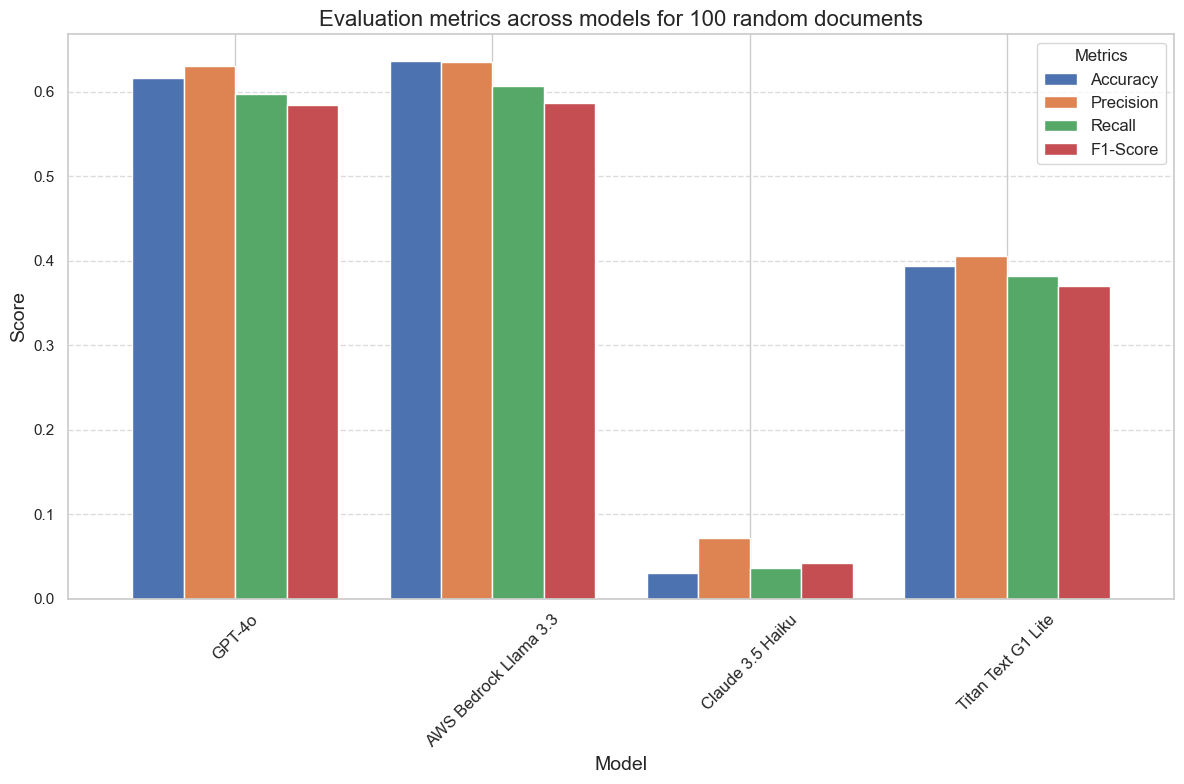

Evaluation Metrics:
                Model  Accuracy  Precision   Recall  F1-Score
               GPT-4o  0.616162   0.630397 0.597876  0.584236
AWS Bedrock Llama 3.3  0.636364   0.635786 0.606708  0.586886
     Claude 3.5 Haiku  0.030303   0.072314 0.036869  0.042424
   Titan Text G1 Lite  0.393939   0.406364 0.382506  0.370003


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

results_df = pd.read_csv("all_llm_evaluation_results.csv")

# Model names for evaluation
model_columns = ["predicted_topic_gpt4o", "predicted_topic_llama", "predicted_topic_titan", "predicted_topic_claude"]
model_names = ["GPT-4o", "AWS Bedrock Llama 3.3", "Claude 3.5 Haiku", "Titan Text G1 Lite"]

metrics_data = []

for model_name, model_column in zip(model_names, model_columns):
    report = classification_report(
        results_df["expected_topic"], 
        results_df[model_column], 
        output_dict=True, 
        zero_division=0
    )
    
    metrics_data.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"]
    })

metrics_df = pd.DataFrame(metrics_data)
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
metrics_df.set_index("Model").plot(kind="bar", figsize=(12, 8), width=0.8)
plt.title("Evaluation metrics across models for 100 random documents", fontsize=16)
plt.ylabel("Score", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Metrics", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Print numerical evaluation results
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))

<Figure size 1200x800 with 0 Axes>

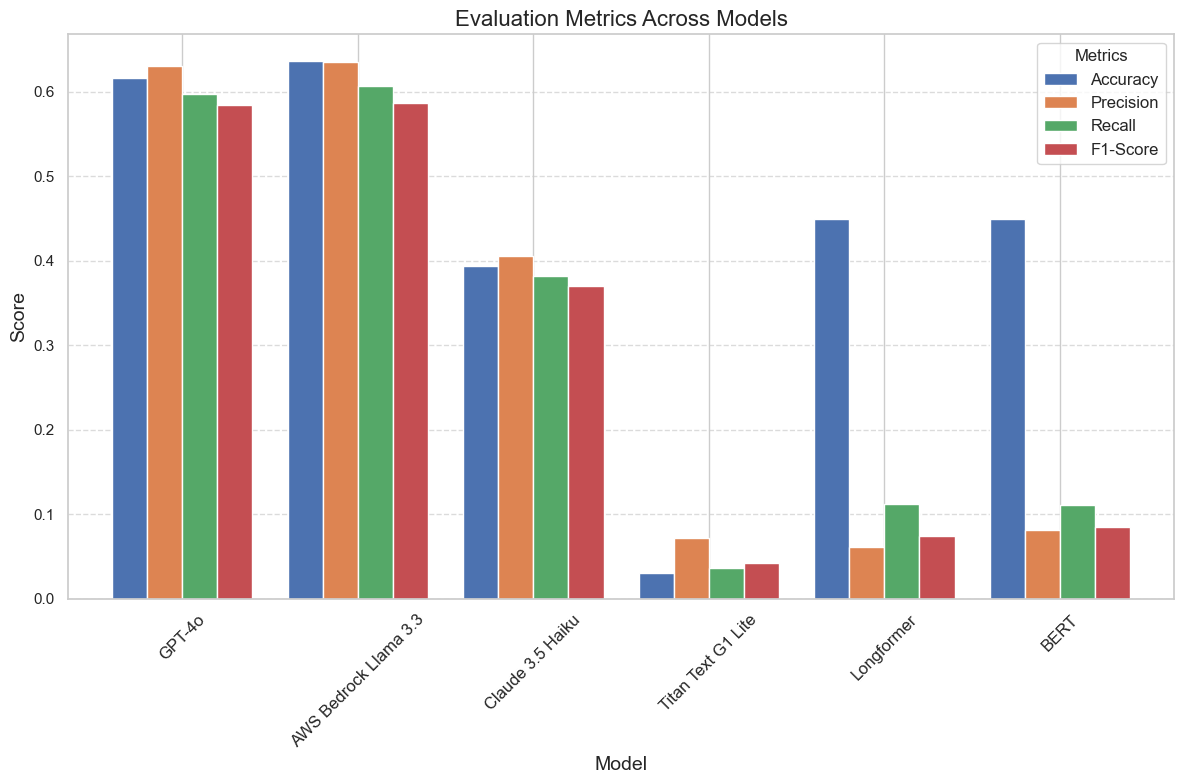

Evaluation Metrics:
                Model  Accuracy  Precision   Recall  F1-Score
               GPT-4o  0.616162   0.630397 0.597876  0.584236
AWS Bedrock Llama 3.3  0.636364   0.635786 0.606708  0.586886
     Claude 3.5 Haiku  0.393939   0.406364 0.382506  0.370003
   Titan Text G1 Lite  0.030303   0.072314 0.036869  0.042424
           Longformer  0.450000   0.061111 0.112750  0.074159
                 BERT  0.450000   0.081268 0.110717  0.085507


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Define model names and expected CSV file locations
model_files = {
    "GPT-4o": "all_llm_evaluation_results.csv",
    "AWS Bedrock Llama 3.3": "all_llm_evaluation_results.csv",
    "Claude 3.5 Haiku": "all_llm_evaluation_results.csv",
    "Titan Text G1 Lite": "all_llm_evaluation_results.csv",
    "Longformer": "longformer_topic_evaluation_results.csv",
    "BERT": "bert_topic_evaluation_results.csv"
}

model_columns = {
    "GPT-4o": "predicted_topic_gpt4o",
    "AWS Bedrock Llama 3.3": "predicted_topic_llama",
    "Claude 3.5 Haiku": "predicted_topic_claude",
    "Titan Text G1 Lite": "predicted_topic_titan",
    "Longformer": "predicted_topic",
    "BERT": "predicted_topic"
}

# Placeholder for evaluation metrics
metrics_data = []

# Process each model
for model_name, file_name in model_files.items():
    results_df = pd.read_csv(file_name)  # Assume files exist
    report = classification_report(
        results_df["expected_topic"], 
        results_df[model_columns[model_name]], 
        output_dict=True, 
        zero_division=0
    )
    
    metrics_data.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"]
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Generate bar plot for model evaluation metrics
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
metrics_df.set_index("Model").plot(kind="bar", figsize=(12, 8), width=0.8)
plt.title("Evaluation Metrics Across Models", fontsize=16)
plt.ylabel("Score", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Metrics", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Print numerical evaluation results
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))

In [44]:
import time

# AWS Bedrock model configurations
MODEL_ID_MISTRAL = "mistral.mistral-large-2407-v1:0"

## BASE

# Define max token limit per request
MAX_TOKENS = 45000  # Adjust as needed

# Function to truncate text to prevent exceeding token limits
def truncate_text(text, max_tokens=MAX_TOKENS):
    words = text.split()
    if len(words) > max_tokens:
        print(f"Warning: Truncating input text to {max_tokens} tokens.")
        return " ".join(words[:max_tokens])
    return text

# AWS Bedrock (Mistral Large model)
def evaluate_topic_with_mistral(file_content):
    try:
        file_content = truncate_text(file_content)
        prompt = f"Classify the following text into only one of these topics: {unique_topics_str}. \n{file_content}"
        # Embed the prompt in Mistral's instruction format.
        formatted_prompt = f"<s>[INST] {prompt} [/INST]"

        native_request = {
            "prompt": formatted_prompt,
            "max_tokens": 512,
            "temperature": 0,
            "top_p": 1,
        }

        request = json.dumps(native_request)

        response = client.invoke_model(modelId=MODEL_ID_MISTRAL, body=request)

        # Decode the response body.
        model_response = json.loads(response["body"].read())
        
        # Extract and print the response text.
        response_text = model_response["choices"][0]["message"]['content']
        
        if not response_text:
            print("Empty response from Mistral API, defaulting to unknown.")
            return "unknown"

        return map_to_category(response_text)

    except (ClientError, Exception) as e:
        print(f"ERROR: Can't invoke Mistral API. Reason: {e}")
        return "unknown"

# Evaluate files function with random selection of 100 documents
def evaluate_files():
    results = []
    base_folder = 'Cleaned_Data_v2'

    # Randomly select 100 documents from the dataset
    sampled_mapping = file_topic_mapping.sample(n=100, random_state=42)

    for _, row in sampled_mapping.iterrows():
        relative_path = row['file_name']
        expected_topic = row['folder_name'].strip()

        # Dynamically find the file location
        file_path = find_file_recursive(base_folder, expected_topic, relative_path)

        if not file_path:
            print(f"Error: File not found - {relative_path}")
            continue

        content = read_txt_file(file_path)
        if not content:
            continue

        predicted_topic_mistral = evaluate_topic_with_mistral(content)

        print(f"File: {relative_path}")

        results.append({
            'file_path': file_path,
            'expected_topic': expected_topic,
            'predicted_topic_mistral': predicted_topic_mistral,
        })
        time.sleep(60)

    return pd.DataFrame(results)

# Evaluate randomly selected 100 files
results_df = evaluate_files()

# Save results
output_csv_path = 'mistral_evaluation_results.csv'
results_df.to_csv(output_csv_path, index=False)
print(f"Evaluation results saved to {output_csv_path}")

File: FAQ - Notice on Cyber Hygiene.txt
File: Balance_sheets31March15.txt
File: pwc-iar-2023.txt
File: GEL-NDA.txt
File: gp-financial-3q-2017.txt
File: 2024-money-laundering-risk-assessment-report.txt
File: 3. Nomura Financial Statement.txt
File: liquidity-coverage-ratio-3q-2018.txt
File: Guidance to Capital Markets Intermediaries on Enhancing AMLCFT Frameworks and Controls.txt
File: finanalysis_sample_reports.txt
File: Notice PSN01 dated 2 April 2024.txt
File: condensed-financial-statement-2q-2023-results.txt
File: Compliance Toolkit for Merchant Banks Last Revised 12 September 2024.txt
File: liquidity-coverage-ratio-2q-2017.txt
File: Global Proxy Voting Policy - 2024.txt
File: pillar3-disclosures-2q-2020.txt
File: The Singapore Guide to Conduct and Market Practices for the Wholesale Financial Markets.txt
File: audit-regulatory-report-2023.txt
File: capitalxtend-client-agreement-v10-28112023.txt
File: gp-financial-2q-2020.txt
File: uobar2018.txt
File: Guidelines on Environmental Risk 

<Figure size 1200x800 with 0 Axes>

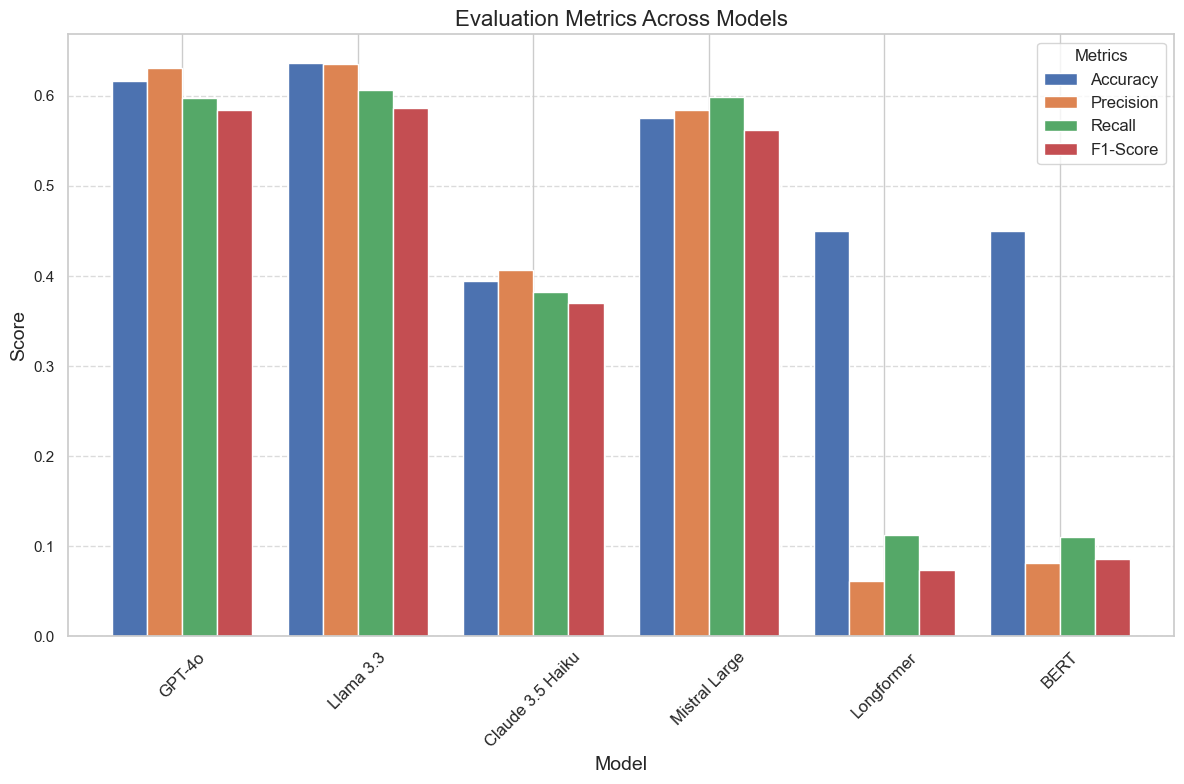

Evaluation Metrics:
           Model  Accuracy  Precision   Recall  F1-Score
          GPT-4o  0.616162   0.630397 0.597876  0.584236
       Llama 3.3  0.636364   0.635786 0.606708  0.586886
Claude 3.5 Haiku  0.393939   0.406364 0.382506  0.370003
   Mistral Large  0.575758   0.584748 0.598396  0.562283
      Longformer  0.450000   0.061111 0.112750  0.074159
            BERT  0.450000   0.081268 0.110717  0.085507


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Define model names and expected CSV file locations
model_files = {
    "GPT-4o": "all_llm_evaluation_results.csv",
    "Llama 3.3": "all_llm_evaluation_results.csv",
    "Claude 3.5 Haiku": "all_llm_evaluation_results.csv",
    "Mistral Large": "mistral_evaluation_results.csv",
    "Longformer": "longformer_topic_evaluation_results.csv",
    "BERT": "bert_topic_evaluation_results.csv"
}

model_columns = {
    "GPT-4o": "predicted_topic_gpt4o",
    "Llama 3.3": "predicted_topic_llama",
    "Claude 3.5 Haiku": "predicted_topic_claude",
    "Mistral Large": "predicted_topic_mistral",
    "Longformer": "predicted_topic",
    "BERT": "predicted_topic"
}

# Placeholder for evaluation metrics
metrics_data = []

# Process each model
for model_name, file_name in model_files.items():
    results_df = pd.read_csv(file_name)  # Assume files exist
    report = classification_report(
        results_df["expected_topic"], 
        results_df[model_columns[model_name]], 
        output_dict=True, 
        zero_division=0
    )
    
    metrics_data.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"]
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Generate bar plot for model evaluation metrics
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
metrics_df.set_index("Model").plot(kind="bar", figsize=(12, 8), width=0.8)
plt.title("Evaluation Metrics Across Models", fontsize=16)
plt.ylabel("Score", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Metrics", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Print numerical evaluation results
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))

=== Longformer Evaluation Report ===
                                    precision    recall  f1-score   support

                    Administrative       0.00      0.00      0.00         1
                    Annual Reports       0.00      0.00      0.00         9
             Anti Money Laundering       0.11      0.60      0.18         5
                     Audit Reports       0.00      0.00      0.00         4
                 Client Agreements       0.00      0.00      0.00         4
                  Consumer Finance       0.00      0.00      0.00         2
                       Derivatives       0.00      0.00      0.00         0
                        Employment       0.00      0.00      0.00         2
             Financial Regulations       0.00      0.00      0.00         3
              Financial Statements       0.83      0.97      0.90        31
    Investment and Market Research       0.00      0.00      0.00         1
                             Loans       0.00     

/Users/jaron/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jaron/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jaron/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jaron/miniconda3/lib/pytho

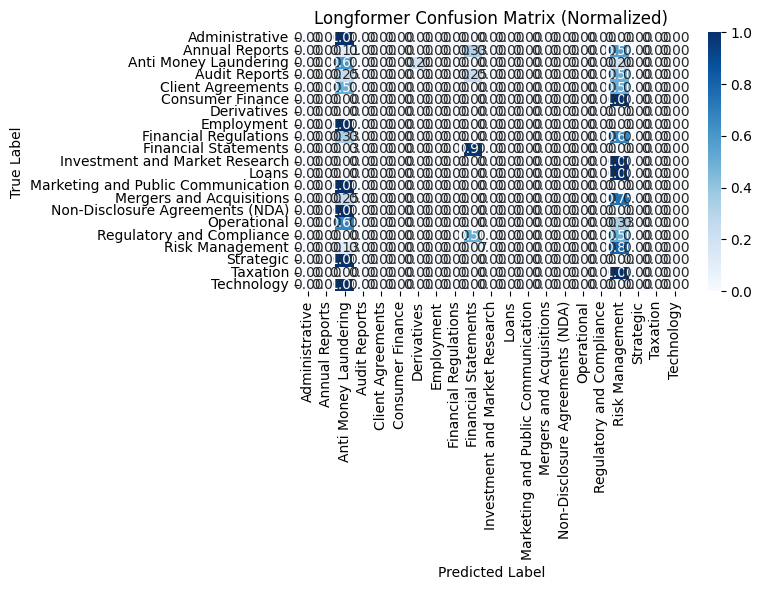

=== BERT Evaluation Report ===
                                    precision    recall  f1-score   support

                    Administrative       0.00      0.00      0.00         1
                    Annual Reports       0.67      0.44      0.53         9
             Anti Money Laundering       0.00      0.00      0.00         5
                     Audit Reports       0.00      0.00      0.00         4
                 Client Agreements       0.00      0.00      0.00         4
                  Consumer Finance       0.00      0.00      0.00         2
                        Employment       0.00      0.00      0.00         2
             Financial Regulations       0.00      0.00      0.00         3
              Financial Statements       0.72      0.90      0.80        31
    Investment and Market Research       0.00      0.00      0.00         1
                             Loans       0.00      0.00      0.00         2
Marketing and Public Communication       0.00      0.00 

/Users/jaron/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jaron/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jaron/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


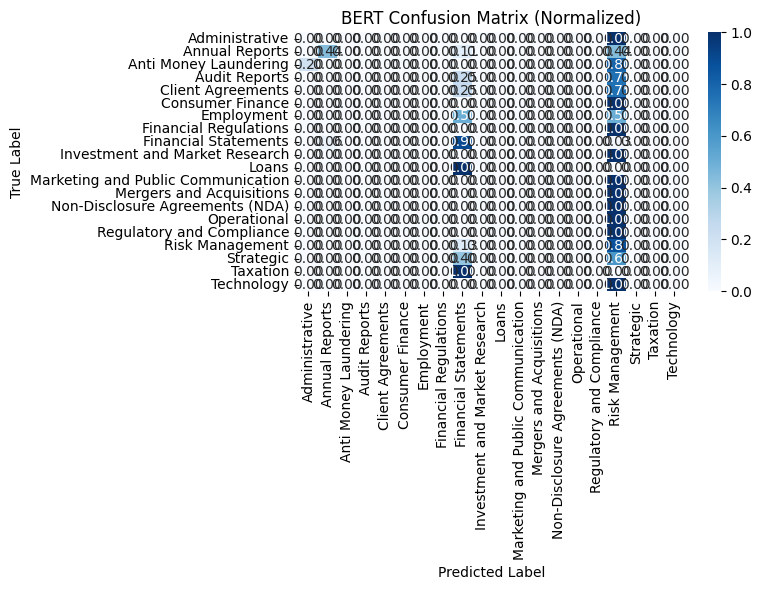

In [18]:
# evaluation_analysis.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

class EvaluationAnalyzer:
    """
    A class to analyze classification evaluation results.
    
    Attributes:
        file_path (str): Path to the CSV file containing predictions.
        model_name (str): Name of the model (for labeling purposes).
    """
    
    def __init__(self, file_path: str, model_name: str):
        self.file_path = file_path
        self.model_name = model_name
        self.df = None
        self.labels = None
        
    def load_data(self):
        """
        Loads evaluation data from a CSV file. Expects columns 'expected_topic' and 'predicted_topic'.
        """
        if not os.path.exists(self.file_path):
            raise FileNotFoundError(f"File {self.file_path} not found.")
        self.df = pd.read_csv(self.file_path)
        # Check that required columns exist
        for col in ['expected_topic', 'predicted_topic']:
            if col not in self.df.columns:
                raise ValueError(f"Expected column '{col}' not found in the data.")
        # Determine unique classes from both true and predicted labels
        self.labels = sorted(list(set(self.df['expected_topic'].unique()).union(set(self.df['predicted_topic'].unique()))))
        
    def compute_metrics(self) -> str:
        """
        Computes the classification report.
        
        Returns:
            A string of the classification report.
        """
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")
            
        report = classification_report(
            self.df['expected_topic'],
            self.df['predicted_topic'],
            labels=self.labels,
            output_dict=False
        )
        return report

    def plot_confusion_matrix(self, normalize: bool = False):
        """
        Plots the confusion matrix.
        
        Args:
            normalize (bool): Whether to normalize the matrix.
        """
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")
            
        cm = confusion_matrix(self.df['expected_topic'], self.df['predicted_topic'], labels=self.labels)
        if normalize:
            # Avoid division by zero by using np.where
            cm_normalized = np.around(cm.astype('float') / np.where(cm.sum(axis=1)[:, None]==0, 1, cm.sum(axis=1)[:, None]), decimals=2)
            cm_to_plot = cm_normalized
        else:
            cm_to_plot = cm
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_to_plot, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                    xticklabels=self.labels, yticklabels=self.labels)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'{self.model_name} Confusion Matrix{" (Normalized)" if normalize else ""}')
        plt.tight_layout()
        plt.show()

    def analyze_per_class_accuracy(self) -> pd.DataFrame:
        """
        Analyzes which classes are predicted well and which are not by calculating per-class accuracy.
        
        Returns:
            A DataFrame with per-class accuracy and support (number of true instances).
        """
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")
            
        # Calculate true positives per class and total true counts
        class_stats = []
        for cls in self.labels:
            true_count = (self.df['expected_topic'] == cls).sum()
            correct_preds = ((self.df['expected_topic'] == cls) & (self.df['predicted_topic'] == cls)).sum()
            # Avoid division by zero
            accuracy = correct_preds / true_count if true_count > 0 else 0.0
            class_stats.append({
                'class': cls,
                'true_count': true_count,
                'correct_predictions': correct_preds,
                'accuracy': accuracy
            })
        return pd.DataFrame(class_stats)

    def run_full_analysis(self, normalize_cm: bool = True):
        """
        Runs the full analysis including metrics computation, confusion matrix plotting,
        and per-class accuracy reporting.
        """
        self.load_data()
        print(f"=== {self.model_name} Evaluation Report ===")
        print(self.compute_metrics())
        print("\nPer-Class Accuracy:")
        per_class_df = self.analyze_per_class_accuracy()
        print(per_class_df)
        self.plot_confusion_matrix(normalize=normalize_cm)
        return per_class_df


if __name__ == "__main__":
    # Example usage: adjust the file paths as needed
    for model_name, file_path in zip(["Longformer", "BERT"], ["longformer_topic_evaluation_results.csv", "bert_topic_evaluation_results.csv"]):
        try:
            analyzer = EvaluationAnalyzer(file_path=file_path, model_name=model_name)
            per_class_accuracy = analyzer.run_full_analysis(normalize_cm=True)
            # Here you might want to further analyze which classes have very low precision.
            # For instance, you might compare the per-class accuracy to the overall class support.
        except Exception as e:
            print(f"Error processing {model_name}: {e}")